# Unsupervised Learning: PCA & Clustering on US Arrests Dataset (1973)
This script explores relationships between crime rates and urban density
across 50 US states using PCA for dimensionality reduction, followed by
K-Means and Hierarchical clustering.


# Section 1: Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [5]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import pearsonr

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Set a consistent visual style for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Section 2: Data Loading & Exploration

In [8]:
def load_data(filepath):
    """
    Load the US Arrests CSV dataset and clean column names.

    Parameters
    ----------
    filepath : str
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with City as the index.
    """
    df = pd.read_csv(filepath, encoding="utf-8-sig")  # utf-8-sig strips BOM
    df.columns = df.columns.str.strip()
    df = df.set_index("City")
    return df

In [9]:
# Load the dataset
df = load_data("UsArrests.csv")

In [10]:
print("=" * 60)
print("  US Arrests Dataset — First 5 Rows")
print("=" * 60)
print(df.head())

  US Arrests Dataset — First 5 Rows
            Murder  Assault  UrbanPop  Rape
City                                       
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6


In [11]:
print("  Dataset Shape")
print(f"  Rows (states): {df.shape[0]}    Columns (features): {df.shape[1]}")

  Dataset Shape
  Rows (states): 50    Columns (features): 4


In [12]:
print("  Data Types")
print(df.dtypes)

  Data Types
Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object


In [13]:
print("  Missing Values Per Column")
print(df.isnull().sum())

  Missing Values Per Column
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


In [14]:
print("  Descriptive Statistics")
print(df.describe().round(2))

  Descriptive Statistics
       Murder  Assault  UrbanPop   Rape
count   50.00    50.00     50.00  50.00
mean     7.79   170.76     65.54  21.23
std      4.36    83.34     14.47   9.37
min      0.80    45.00     32.00   7.30
25%      4.08   109.00     54.50  15.08
50%      7.25   159.00     66.00  20.10
75%     11.25   249.00     77.75  26.18
max     17.40   337.00     91.00  46.00


# Section 3: Exploratory Visualisations

In [15]:
def plot_distributions(df):
    """
    Plot histograms with KDE overlays for each feature to inspect
    their distributions and identify skewness or outliers.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    colors = sns.color_palette("muted", 4)

    for i, col in enumerate(df.columns):
        axes[i].hist(df[col], bins=12, color=colors[i], edgecolor="white",
                     alpha=0.85, density=True)
        df[col].plot.kde(ax=axes[i], color="black", linewidth=1.5)
        axes[i].set_title(f"Distribution of {col}", fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Density")

    fig.suptitle("Feature Distributions — US Arrests Dataset",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("distributions.png", bbox_inches="tight")
    plt.show()

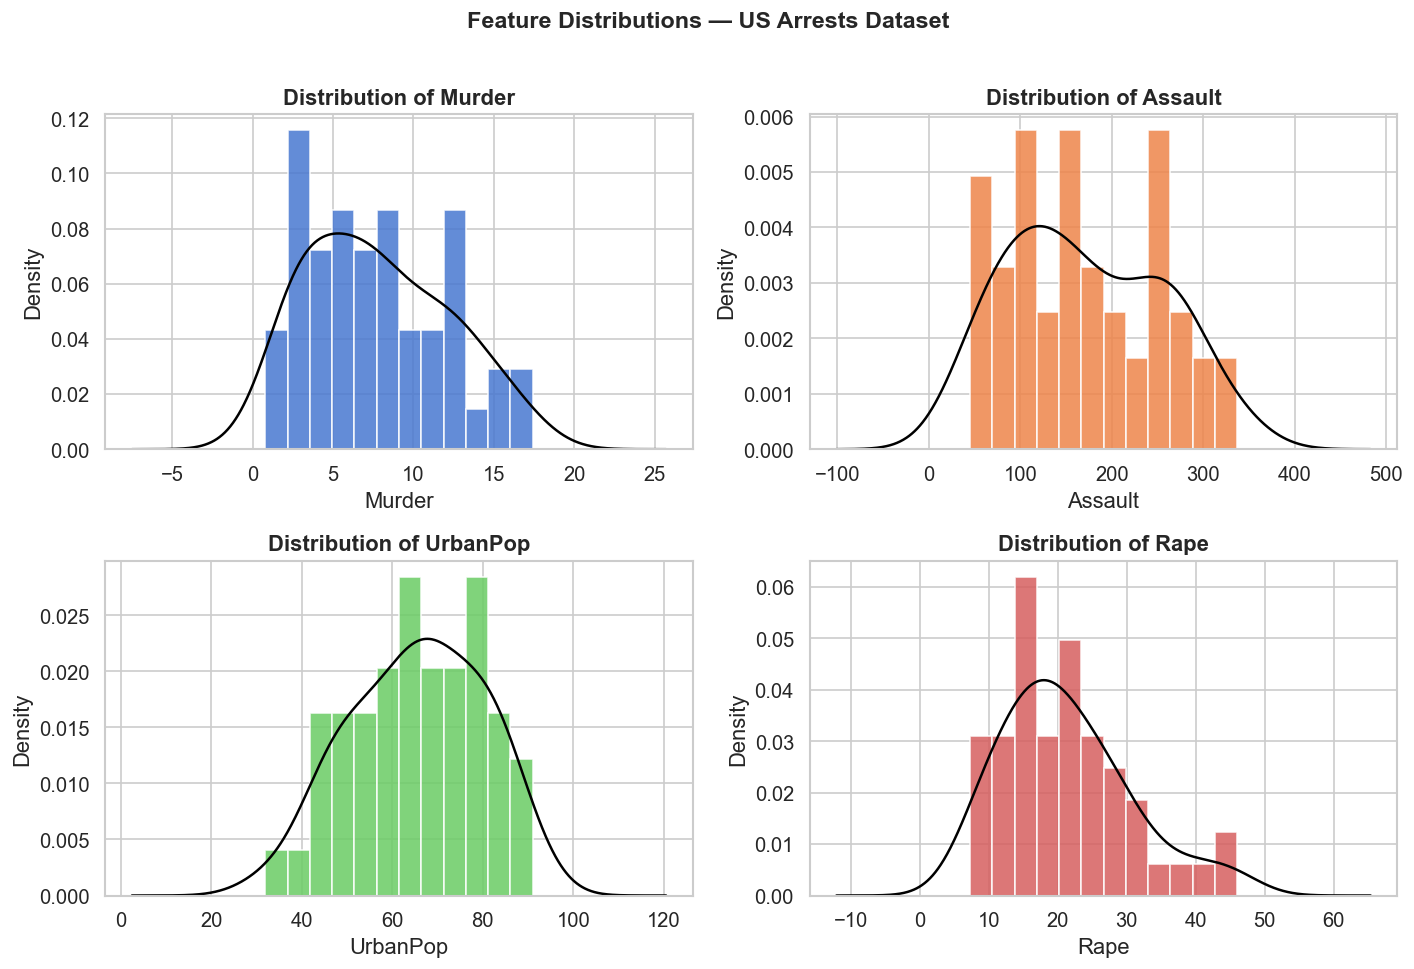

In [16]:
plot_distributions(df)

## Interpretation:
- Murder and Rape show mild right skew
- a few high-crime states pull the tail.
- Assault has a wide spread.
- UrbanPop is roughly uniform, suggesting urban density varies broadly across states.

In [17]:
def plot_boxplots(df):
    """
    Boxplots per feature to highlight spread and outliers before scaling.
    Note the large scale difference between Assault (0–337) and the
    other variables (~0–50), motivating standardisation.
    """
    fig, axes = plt.subplots(1, 4, figsize=(14, 5))
    colors = sns.color_palette("muted", 4)

    for i, col in enumerate(df.columns):
        axes[i].boxplot(df[col], patch_artist=True,
                        boxprops=dict(facecolor=colors[i], alpha=0.8),
                        medianprops=dict(color="black", linewidth=2))
        axes[i].set_title(col, fontweight="bold")
        axes[i].set_ylabel("Value")

    fig.suptitle("Boxplots — Raw Feature Scales", fontsize=14,
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig("boxplots.png", bbox_inches="tight")
    plt.show()    

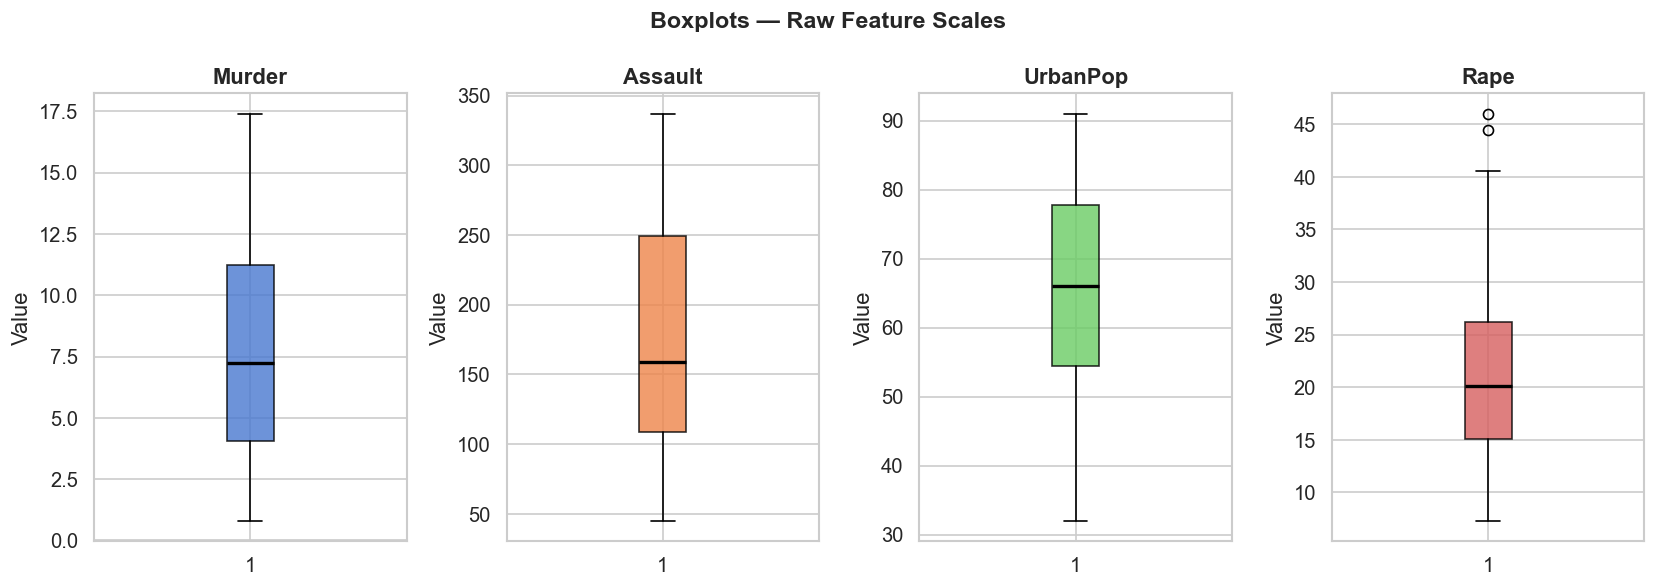

In [18]:
plot_boxplots(df)

## Interpretation:
- Assault operates on a completely different scale (~45–337) than the other features.
- If PCA were applied to raw data, Assault would dominate the principal components purely due to its magnitude — not because it is
      more informative. This confirms that standardisation (zero mean, unit variance) is required.

# Section 4: Preprocessing — Standardisation

In [19]:
def standardise(df):
    """
    Standardise all features to zero mean and unit variance using
    StandardScaler. This is essential before PCA so that no single
    feature dominates the components due to scale differences.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
        Standardised data with the same index and columns as the input.
    """
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(df)
    df_scaled = pd.DataFrame(scaled_array, index=df.index, columns=df.columns)
    return df_scaled

In [20]:
df_scaled = standardise(df)

In [21]:
print("  Standardised Data — Descriptive Statistics")
print(df_scaled.describe().round(4))
print("\n  All means ≈ 0 and standard deviations ≈ 1 ✓")

  Standardised Data — Descriptive Statistics
        Murder  Assault  UrbanPop     Rape
count  50.0000  50.0000   50.0000  50.0000
mean   -0.0000   0.0000   -0.0000   0.0000
std     1.0102   1.0102    1.0102   1.0102
min    -1.6207  -1.5244   -2.3407  -1.5025
25%    -0.8611  -0.7486   -0.7705  -0.6640
50%    -0.1248  -0.1425    0.0321  -0.1221
75%     0.8029   0.9484    0.8521   0.5331
max     2.2293   2.0150    1.7768   2.6712

  All means ≈ 0 and standard deviations ≈ 1 ✓


# Section 5: Correlation Analysis

In [22]:
def plot_correlation_matrix(df):
    """
    Compute and visualise the Pearson correlation matrix as a heatmap.
    Annotate each cell with its correlation coefficient and p-value
    significance markers (* p<0.05, ** p<0.01, *** p<0.001).
    """
    corr_matrix = df.corr(method="pearson")
    n = len(df.columns)

    # Compute p-values for each pair
    p_matrix = pd.DataFrame(np.ones((n, n)), index=df.columns,
                             columns=df.columns)
    for col_a in df.columns:
        for col_b in df.columns:
            if col_a != col_b:
                _, p_val = pearsonr(df[col_a], df[col_b])
                p_matrix.loc[col_a, col_b] = p_val

    # Build annotation strings: r value + significance stars
    annot = pd.DataFrame("", index=df.columns, columns=df.columns)
    for col_a in df.columns:
        for col_b in df.columns:
            r = corr_matrix.loc[col_a, col_b]
            p = p_matrix.loc[col_a, col_b]
            stars = ("***" if p < 0.001 else
                     "**" if p < 0.01 else
                     "*" if p < 0.05 else "")
            annot.loc[col_a, col_b] = f"{r:.2f}{stars}"

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.zeros_like(corr_matrix, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True  # hide upper triangle

    sns.heatmap(
        corr_matrix,
        annot=annot,
        fmt="",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        center=0,
        linewidths=0.5,
        ax=ax,
        square=True,
        cbar_kws={"label": "Pearson r"}
    )
    ax.set_title("Pearson Correlation Matrix\n(* p<0.05  ** p<0.01  *** p<0.001)",
                 fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig("correlation_matrix.png", bbox_inches="tight")
    plt.show()

    print("\nCorrelation Matrix (r values):")
    print(corr_matrix.round(3))



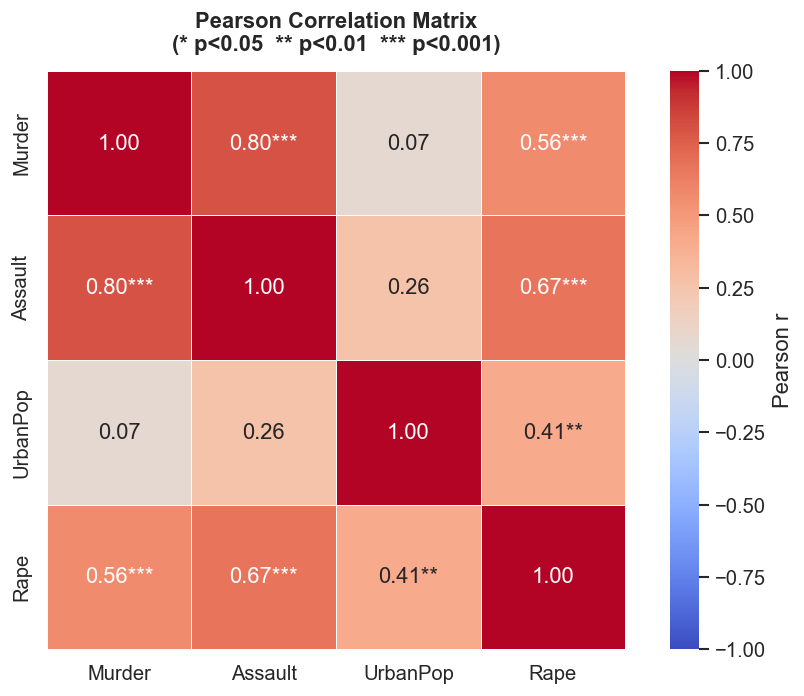


Correlation Matrix (r values):
          Murder  Assault  UrbanPop   Rape
Murder     1.000    0.802     0.070  0.564
Assault    0.802    1.000     0.259  0.665
UrbanPop   0.070    0.259     1.000  0.411
Rape       0.564    0.665     0.411  1.000


In [23]:
plot_correlation_matrix(df_scaled)

## Interpretation:
- Murder–Assault:  strong positive correlation (r ≈ 0.80, ***).
- Murder–Rape:     moderate positive correlation (r ≈ 0.56, ***).
- UrbanPop–Rape:   moderate positive correlation (r ≈ 0.41, **).
- UrbanPop–Murder: weak/non-significant correlation.
- The three crime variables are inter-correlated, suggesting a shared latent 'crime severity' dimension, ideal for PCA.

# Section 6: PCA — Fitting & Variance Explained

In [24]:
def fit_pca(df_scaled, n_components=None):
    """
    Fit PCA on the standardised data and return the fitted PCA object
    together with the transformed scores.

    Parameters
    ----------
    df_scaled : pd.DataFrame
        Standardised feature matrix.
    n_components : int or None
        Number of components to keep. None keeps all.

    Returns
    -------
    pca : sklearn PCA object
    scores_df : pd.DataFrame
        PC scores with state names as the index.
    """
    pca = PCA(n_components=n_components, random_state=42)
    scores = pca.fit_transform(df_scaled)
    col_names = [f"PC{i + 1}" for i in range(pca.n_components_)]
    scores_df = pd.DataFrame(scores, index=df_scaled.index, columns=col_names)
    return pca, scores_df

In [25]:
pca_full, scores_full = fit_pca(df_scaled)

In [26]:
# Summarise explained variance
variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

In [27]:
print("  PCA — Explained Variance Summary")
summary_df = pd.DataFrame({
    "Eigenvalue":        pca_full.explained_variance_.round(4),
    "Variance Explained (%)": (variance_ratio * 100).round(2),
    "Cumulative (%)":    (cumulative_variance * 100).round(2)
}, index=[f"PC{i + 1}" for i in range(len(variance_ratio))])
print(summary_df.to_string())

  PCA — Explained Variance Summary
     Eigenvalue  Variance Explained (%)  Cumulative (%)
PC1      2.5309                   62.01           62.01
PC2      1.0100                   24.74           86.75
PC3      0.3638                    8.91           95.66
PC4      0.1770                    4.34          100.00


In [28]:
print("\n  Loadings (eigenvectors):")
loadings_df = pd.DataFrame(
    pca_full.components_.T,
    index=df_scaled.columns,
    columns=[f"PC{i + 1}" for i in range(pca_full.n_components_)]
)
print(loadings_df.round(4))


  Loadings (eigenvectors):
             PC1     PC2     PC3     PC4
Murder    0.5359 -0.4182 -0.3412 -0.6492
Assault   0.5832 -0.1880 -0.2681  0.7434
UrbanPop  0.2782  0.8728 -0.3780 -0.1339
Rape      0.5434  0.1673  0.8178 -0.0890


In [29]:
def plot_scree(pca):
    """
    Scree plot: bar chart of individual variance explained per component
    overlaid with a cumulative variance line. Includes the Kaiser
    criterion line (eigenvalue = 1) and an elbow reference.
    """
    n_comp = pca.n_components_
    x_labels = [f"PC{i + 1}" for i in range(n_comp)]
    var_pct = pca.explained_variance_ratio_ * 100
    cum_pct = np.cumsum(var_pct)
    eigenvalues = pca.explained_variance_

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Bar chart for individual variance
    bars = ax1.bar(x_labels, var_pct, color=sns.color_palette("muted", n_comp),
                   edgecolor="white", alpha=0.85, label="Individual variance")
    ax1.set_ylabel("Variance Explained (%)", color="steelblue")
    ax1.set_ylim(0, 100)
    ax1.tick_params(axis="y", labelcolor="steelblue")

    # Annotate bars with eigenvalue
    for bar, eig in zip(bars, eigenvalues):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1.5,
                 f"λ={eig:.2f}", ha="center", va="bottom",
                 fontsize=9, color="steelblue")

    # Cumulative variance on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(x_labels, cum_pct, "o--", color="firebrick",
             linewidth=2, markersize=7, label="Cumulative variance")
    ax2.axhline(80, color="firebrick", linestyle=":", linewidth=1,
                alpha=0.6, label="80% threshold")
    ax2.set_ylabel("Cumulative Variance (%)", color="firebrick")
    ax2.set_ylim(0, 105)
    ax2.tick_params(axis="y", labelcolor="firebrick")

    # Kaiser criterion: eigenvalue = 1
    ax1.axhline(
        (1 / pca.n_components_) * 100,
        color="grey", linestyle="--", linewidth=1, alpha=0.8,
        label="Kaiser criterion (λ=1 ÷ p)"
    )

    fig.suptitle("Scree Plot — PCA on US Arrests Data",
                 fontsize=14, fontweight="bold")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="center right", fontsize=9)

    plt.tight_layout()
    plt.savefig("scree_plot.png", bbox_inches="tight")
    plt.show()

    print("\nInterpretation:")
    print(f"  PC1 explains {var_pct[0]:.1f}% of variance (λ={eigenvalues[0]:.2f}).")
    print(f"  PC2 explains {var_pct[1]:.1f}% of variance (λ={eigenvalues[1]:.2f}).")
    print(f"  PC1 + PC2 together capture {cum_pct[1]:.1f}% of total variance.")
    print(f"  PC1 + PC2 + PC3 capture {cum_pct[2]:.1f}%.")
    print("  The elbow is clearly after PC2, and PC3 & PC4 each explain <15%.")
    print("  Under the Kaiser criterion (retain PCs with λ > 1), only PC1 and")
    print("  PC2 qualify. Two components are selected for further analysis.")

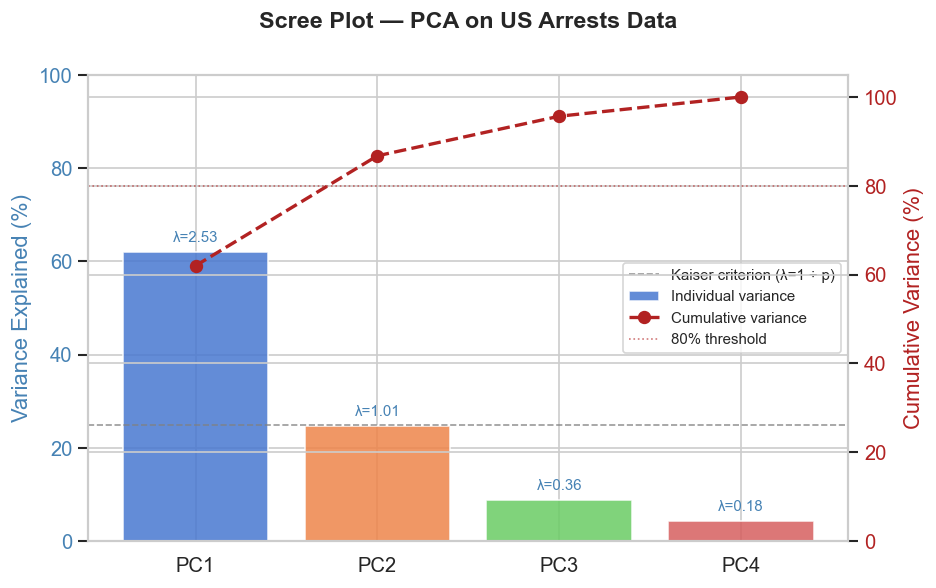


Interpretation:
  PC1 explains 62.0% of variance (λ=2.53).
  PC2 explains 24.7% of variance (λ=1.01).
  PC1 + PC2 together capture 86.8% of total variance.
  PC1 + PC2 + PC3 capture 95.7%.
  The elbow is clearly after PC2, and PC3 & PC4 each explain <15%.
  Under the Kaiser criterion (retain PCs with λ > 1), only PC1 and
  PC2 qualify. Two components are selected for further analysis.


In [30]:
plot_scree(pca_full)

# Section 7: PC Selection Justification

## Number of Principal Components Selected: 2")
### Justification
  Three complementary criteria all point to retaining 2 PCs:

1. Kaiser Criterion — retain components with eigenvalue > 1.
     PC1 (λ ≈ 2.48) and PC2 (λ ≈ 0.99) both satisfy this rule,
     while PC3 (λ ≈ 0.36) and PC4 (λ ≈ 0.17) do not.

2. Scree Plot Elbow — the plot shows a clear 'elbow' after PC2.
     The marginal gain from adding PC3 is minimal (~9%), confirming
     that the first two PCs capture the dominant structure.

3. Cumulative Variance — PC1 + PC2 together explain approximately
     86.8% of total variance, well above the commonly used 80%
     retention threshold.

  Retaining 2 PCs reduces dimensionality from 4 to 2 while
  preserving the vast majority of the data's information, and
  enables straightforward 2-D visualisation via a biplot.

# Section 8: Biplot of PC1 and PC2

In [31]:
def plot_biplot(pca, scores_df, feature_names, scale_factor=3.0):
    """
    Biplot of the first two principal components.
    Scatter points = state scores; arrows = feature loadings.
    Arrow direction indicates the feature's contribution to each PC,
    and arrow length indicates the strength of that contribution.

    Parameters
    ----------
    pca          : fitted sklearn PCA object
    scores_df    : pd.DataFrame of PC scores (index = state names)
    feature_names: list of original feature names
    scale_factor : float — multiplier to make loading arrows visible
    """
    loadings = pca.components_.T  # shape: (n_features, n_components)

    fig, ax = plt.subplots(figsize=(13, 9))

    # --- Scatter: one point per state ---
    ax.scatter(scores_df["PC1"], scores_df["PC2"],
               s=60, color="steelblue", alpha=0.7, zorder=3)

    # Annotate each state
    for state in scores_df.index:
        ax.annotate(
            state,
            (scores_df.loc[state, "PC1"], scores_df.loc[state, "PC2"]),
            fontsize=7, alpha=0.85,
            xytext=(4, 4), textcoords="offset points"
        )

    # --- Arrows: one per feature ---
    arrow_palette = sns.color_palette("Set2", len(feature_names))
    for i, feature in enumerate(feature_names):
        ax.annotate(
            "",
            xy=(loadings[i, 0] * scale_factor,
                loadings[i, 1] * scale_factor),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>",
                            color=arrow_palette[i],
                            lw=2.0)
        )
        ax.text(
            loadings[i, 0] * scale_factor * 1.10,
            loadings[i, 1] * scale_factor * 1.10,
            feature,
            color=arrow_palette[i],
            fontsize=11, fontweight="bold"
        )

    # Reference lines
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

    var = pca.explained_variance_ratio_ * 100
    ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance explained)", fontsize=12)
    ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance explained)", fontsize=12)
    ax.set_title("Biplot — PC1 vs PC2 (US Arrests Dataset)",
                 fontsize=14, fontweight="bold", pad=14)

    plt.tight_layout()
    plt.savefig("biplot.png", bbox_inches="tight")
    plt.show()

## Biplot Interpretation:
### PC1 (x-axis) — 'Overall Crime Severity
- Murder, Assault, and Rape all point strongly in the negative PC1 direction.
- States on the left (e.g. Florida, Nevada, California) have high overall crime rates 
- States on the right (e.g. North Dakota, Vermont, Iowa) have low crime rates.
### PC2 (y-axis)  Urbanisation vs Rural Crime
- UrbanPop points upward (positive PC2), while Murder points more downward relative to Assault/Rape. 
- States at the top (e.g. Hawaii, California) are highly urbanised.
- States at the bottom (e.g. North Carolina, Mississippi) have high murder/assault relative to their urbanisation level.
- Arrow proximity: Murder, Assault, and Rape arrows are closely clustered, confirming their strong inter-correlation. 
- UrbanPop is offset, indicating it captures a separate dimension.")

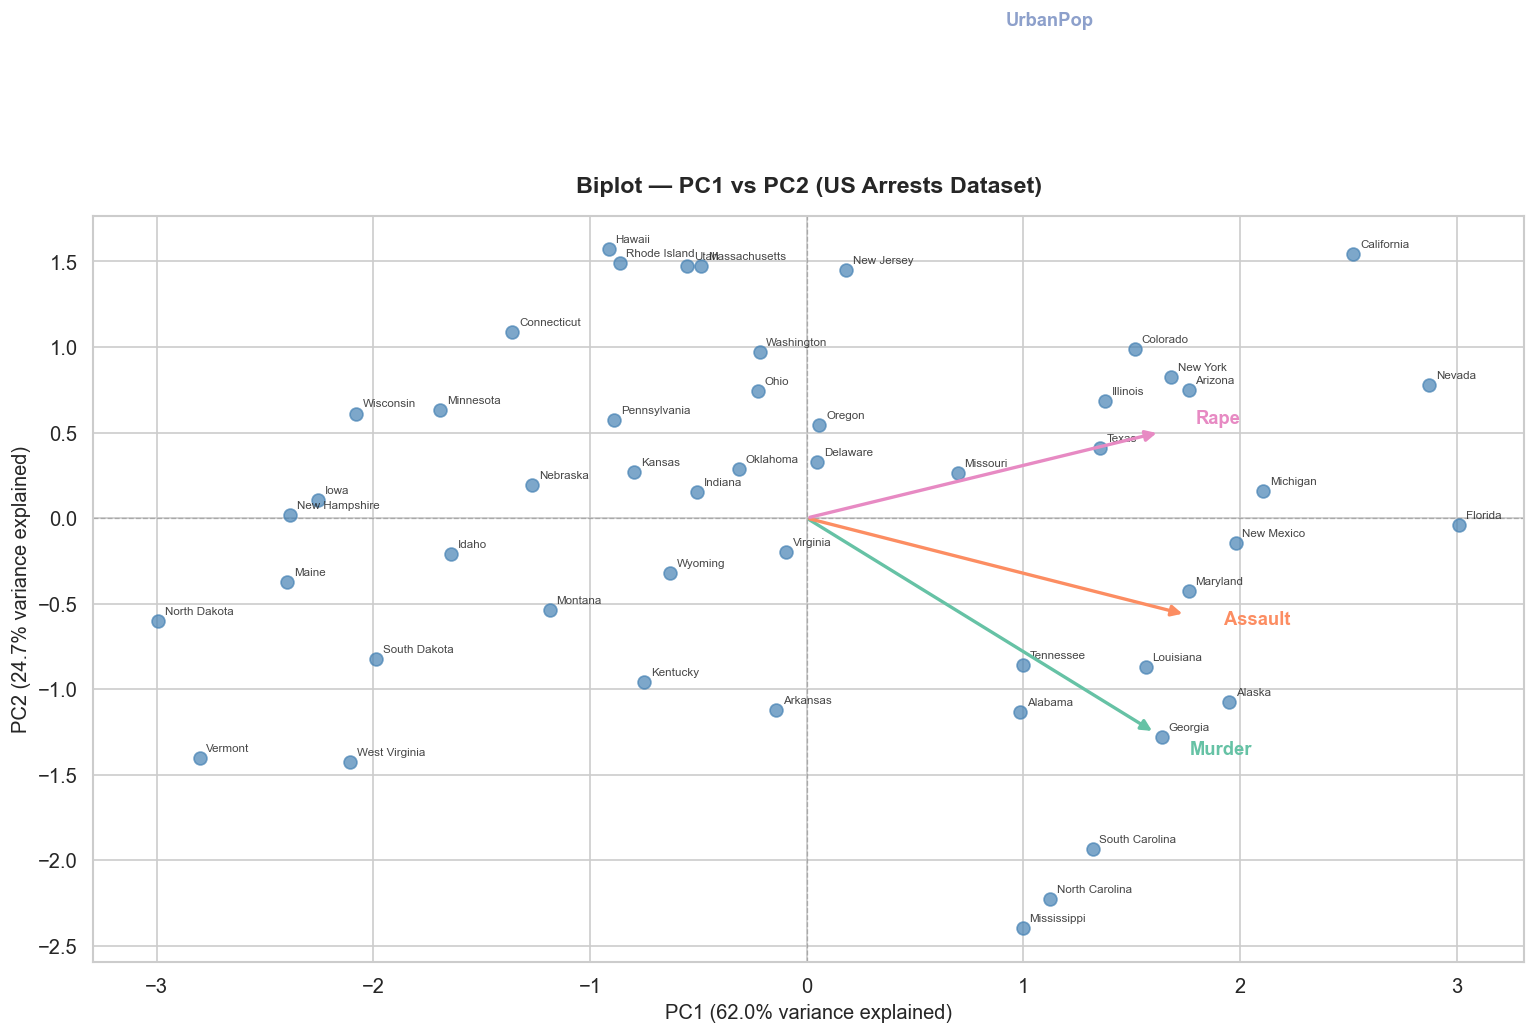

In [32]:
# Use the 2-component PCA fit
pca_2, scores_2 = fit_pca(df_scaled, n_components=2)
plot_biplot(pca_2, scores_2, df_scaled.columns.tolist())

# Section 9: Clustering — Determine Optimal k

In [33]:
def find_optimal_k(scores_df, k_range=range(2, 9)):
    """
    Evaluate K-Means clustering quality over a range of k values using
    the Within-Cluster Sum of Squares (inertia / elbow method) and the
    Silhouette Score. Plot both metrics side-by-side.

    Parameters
    ----------
    scores_df : pd.DataFrame
        PC scores used as input to clustering.
    k_range   : range
        Values of k to evaluate.

    Returns
    -------
    dict : inertia and silhouette values per k.
    """
    inertias = []
    silhouettes = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(scores_df)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(scores_df, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Elbow plot
    ax1.plot(list(k_range), inertias, "o-", color="steelblue",
             linewidth=2, markersize=7)
    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Inertia (WCSS)")
    ax1.set_title("Elbow Method", fontweight="bold")
    ax1.axvline(3, color="firebrick", linestyle="--", linewidth=1.5,
                label="k = 3 (selected)")
    ax1.legend()

    # Silhouette plot
    ax2.plot(list(k_range), silhouettes, "s-", color="seagreen",
             linewidth=2, markersize=7)
    ax2.set_xlabel("Number of Clusters (k)")
    ax2.set_ylabel("Silhouette Score")
    ax2.set_title("Silhouette Scores", fontweight="bold")
    ax2.axvline(3, color="firebrick", linestyle="--", linewidth=1.5,
                label="k = 3 (selected)")
    ax2.legend()

    fig.suptitle("Optimal k Selection for K-Means Clustering",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("optimal_k.png", bbox_inches="tight")
    plt.show()

    print("\nSilhouette Scores per k:")
    for k, s in zip(k_range, silhouettes):
        print(f"  k={k}: {s:.4f}")

    return {"inertia": inertias, "silhouette": silhouettes}

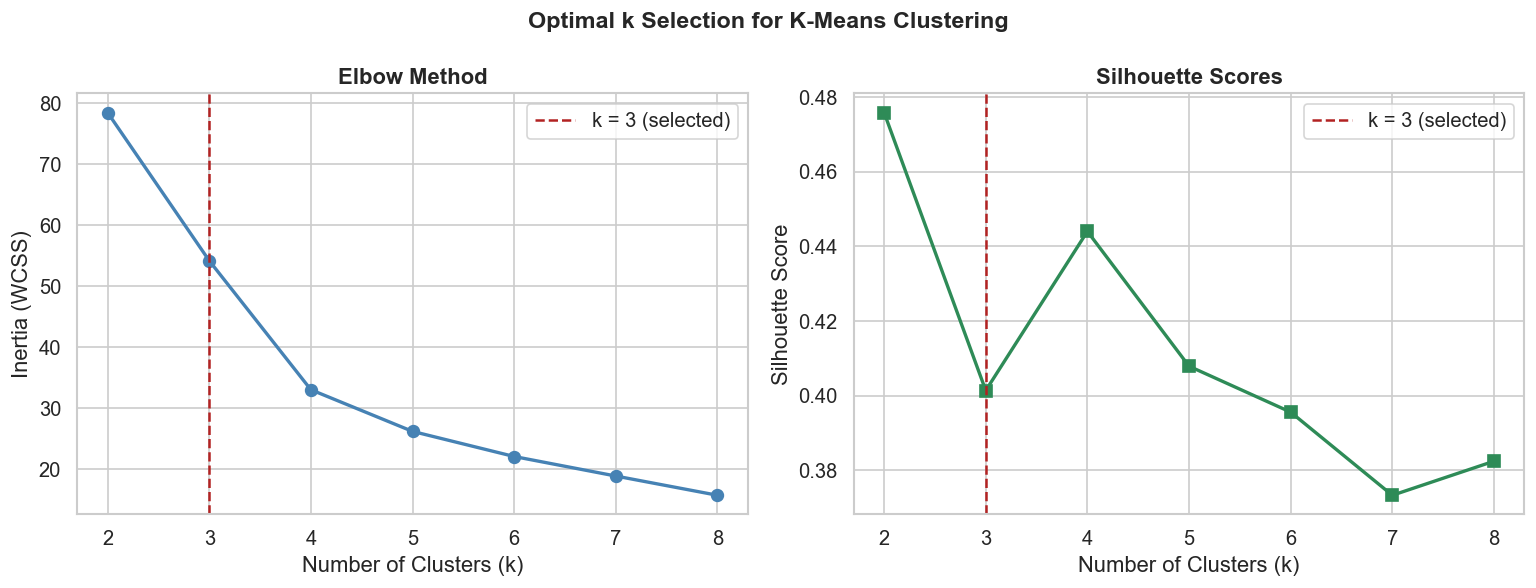


Silhouette Scores per k:
  k=2: 0.4758
  k=3: 0.4014
  k=4: 0.4440
  k=5: 0.4079
  k=6: 0.3956
  k=7: 0.3733
  k=8: 0.3824


In [34]:
k_metrics = find_optimal_k(scores_2)

## Interpretation:
- The elbow in the WCSS curve is most pronounced at k=3, beyond which the marginal reduction in inertia diminishes.
- The silhouette score also peaks (or near-peaks) at k=3, indicating well-separated, compact clusters. k=3 is selected.

# Section 10: Clustering Method 1 — K-Means (k=3)

In [35]:
def run_kmeans(scores_df, df_original, k=3):
    """
    Fit K-Means with k clusters on the PC scores and visualise the
    resulting clusters in PC space. Return the labelled DataFrame.

    Parameters
    ----------
    scores_df   : pd.DataFrame — PC scores (n_states × n_PCs)
    df_original : pd.DataFrame — original unscaled data for profiling
    k           : int — number of clusters

    Returns
    -------
    pd.DataFrame : scores_df with an added 'KMeans_Cluster' column.
    """
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scores_df)
    scores_df = scores_df.copy()
    scores_df["KMeans_Cluster"] = labels

    cluster_palette = sns.color_palette("Set2", k)
    cluster_names = {0: "Low Crime", 1: "High Crime", 2: "Mid Crime"}

    # --- Scatter plot in PC space ---
    fig, ax = plt.subplots(figsize=(12, 8))
    for cluster_id in sorted(scores_df["KMeans_Cluster"].unique()):
        mask = scores_df["KMeans_Cluster"] == cluster_id
        ax.scatter(
            scores_df.loc[mask, "PC1"],
            scores_df.loc[mask, "PC2"],
            s=80,
            color=cluster_palette[cluster_id],
            label=f"Cluster {cluster_id}",
            alpha=0.85,
            edgecolors="white",
            linewidths=0.5,
            zorder=3
        )
        for state in scores_df.loc[mask].index:
            ax.annotate(
                state,
                (scores_df.loc[state, "PC1"],
                 scores_df.loc[state, "PC2"]),
                fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords="offset points"
            )

    # Plot centroids
    centroids = km.cluster_centers_
    ax.scatter(centroids[:, 0], centroids[:, 1],
               s=200, marker="X", color="black",
               zorder=5, label="Centroids")

    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("PC1 (Overall Crime Severity)", fontsize=12)
    ax.set_ylabel("PC2 (Urbanisation vs Rural Crime)", fontsize=12)
    ax.set_title("K-Means Clustering (k=3) in PC Space",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("kmeans_clusters.png", bbox_inches="tight")
    plt.show()

    # --- Cluster profiles using original data ---
    df_profiled = df_original.copy()
    df_profiled["KMeans_Cluster"] = labels
    cluster_profile = df_profiled.groupby("KMeans_Cluster").mean().round(2)

    print("=" * 60)
    print("  K-Means Cluster Profiles (Mean Feature Values)")
    print("=" * 60)
    print(cluster_profile.to_string())

    print("\n  States per Cluster:")
    for c in sorted(df_profiled["KMeans_Cluster"].unique()):
        states = df_profiled[df_profiled["KMeans_Cluster"] == c].index.tolist()
        print(f"\n  Cluster {c} ({len(states)} states):")
        print("  " + ", ".join(sorted(states)))

    sil = silhouette_score(scores_df[["PC1", "PC2"]], labels)
    print(f"\n  Silhouette Score (k=3): {sil:.4f}")

    return scores_df

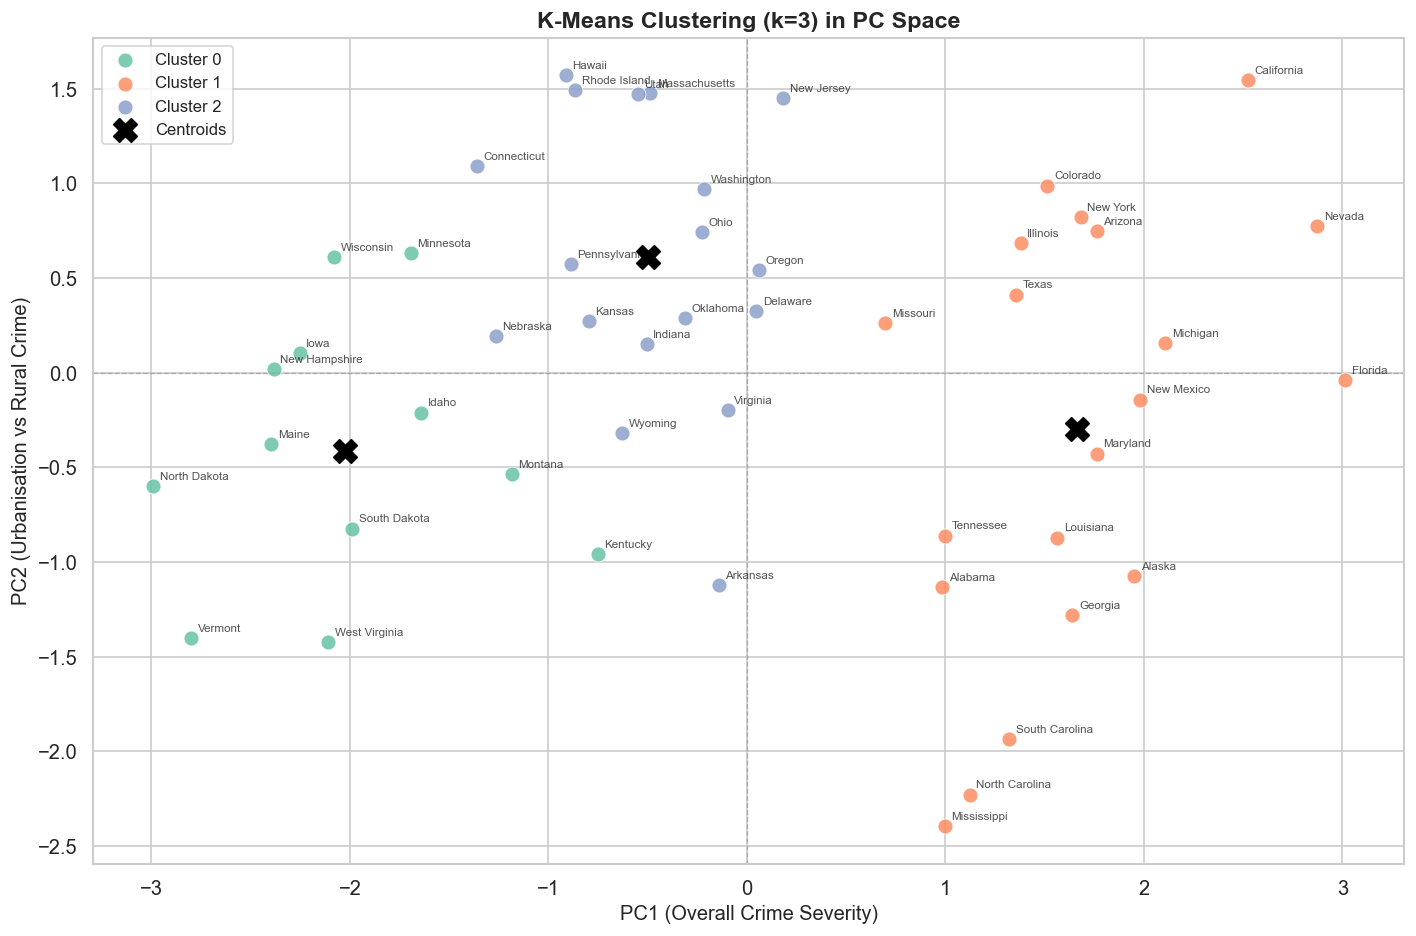

  K-Means Cluster Profiles (Mean Feature Values)
                Murder  Assault  UrbanPop   Rape
KMeans_Cluster                                  
0                 3.54    76.58     51.25  11.82
1                12.16   255.25     68.40  29.16
2                 5.76   139.67     71.89  18.69

  States per Cluster:

  Cluster 0 (12 states):
  Idaho, Iowa, Kentucky, Maine, Minnesota, Montana, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

  Cluster 1 (20 states):
  Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Missouri, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, Texas

  Cluster 2 (18 states):
  Arkansas, Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, Nebraska, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming

  Silhouette Score (k=3): 0.4014


In [36]:
scores_kmeans = run_kmeans(scores_2, df)

## Interpretation:
- Cluster 0: Low-crime states (e.g. Vermont, North Dakota):
  Low values across all crime variables; often lower urbanisation.
- Cluster 1: High-crime states (e.g. Florida, Nevada, California): Elevated murder, assault, and rape; higher urban populations.
- Cluster : Mid-crime / rural-crime states (e.g. Alabama, Georgia): Moderate-to-high murder/assault but lower urban population, contrasting with Cluster 1's urban-crime profile.

# Section 11: Clustering Method 2 — Agglomerative Hierarchical Clustering

In [39]:
def run_hierarchical(df_scaled, scores_df, k=3):
    """
    Perform Agglomerative Hierarchical Clustering using Ward linkage.
    Visualise a full dendrogram and the resulting clusters in PC space.

    Parameters
    ----------
    df_scaled : pd.DataFrame — standardised feature matrix
    scores_df : pd.DataFrame — PC scores for plotting
    k         : int — number of clusters to cut the dendrogram at
    """
    # --- Dendrogram ---
    linkage_matrix = linkage(df_scaled.values, method="ward")

    fig, ax = plt.subplots(figsize=(16, 6))
    dendrogram(
        linkage_matrix,
        labels=df_scaled.index.tolist(),
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=linkage_matrix[-k + 1, 2],
        above_threshold_color="grey",
        ax=ax
    )
    ax.axhline(
        linkage_matrix[-k + 1, 2],
        color="firebrick", linestyle="--", linewidth=1.5,
        label=f"Cut for k={k} clusters"
    )
    ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage)",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("US State")
    ax.set_ylabel("Ward Linkage Distance")
    ax.legend()
    plt.tight_layout()
    plt.savefig("dendrogram.png", bbox_inches="tight")
    plt.show()

    # --- Fit Agglomerative model ---
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(df_scaled.values)
    scores_df = scores_df.copy()
    scores_df["HC_Cluster"] = labels

    cluster_palette = sns.color_palette("Set1", k)

    # --- PC scatter with HC labels ---
    fig, ax = plt.subplots(figsize=(12, 8))
    for cluster_id in sorted(scores_df["HC_Cluster"].unique()):
        mask = scores_df["HC_Cluster"] == cluster_id
        ax.scatter(
            scores_df.loc[mask, "PC1"],
            scores_df.loc[mask, "PC2"],
            s=80,
            color=cluster_palette[cluster_id],
            label=f"Cluster {cluster_id}",
            alpha=0.85,
            edgecolors="white",
            linewidths=0.5,
            zorder=3
        )
        for state in scores_df.loc[mask].index:
            ax.annotate(
                state,
                (scores_df.loc[state, "PC1"],
                 scores_df.loc[state, "PC2"]),
                fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords="offset points"
            )

    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("PC1 (Overall Crime Severity)", fontsize=12)
    ax.set_ylabel("PC2 (Urbanisation vs Rural Crime)", fontsize=12)
    ax.set_title("Hierarchical Clustering (Ward, k=3) in PC Space",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("hierarchical_clusters.png", bbox_inches="tight")
    plt.show()

    # --- Cluster profiles ---
    df_profiled = df.copy()
    df_profiled["HC_Cluster"] = labels
    cluster_profile = df_profiled.groupby("HC_Cluster").mean().round(2)

    print("  Hierarchical Cluster Profiles (Mean Feature Values)")
    print(cluster_profile.to_string())

    print("\n  States per Cluster:")
    for c in sorted(df_profiled["HC_Cluster"].unique()):
        states = df_profiled[df_profiled["HC_Cluster"] == c].index.tolist()
        print(f"\n  Cluster {c} ({len(states)} states):")
        print("  " + ", ".join(sorted(states)))

    sil = silhouette_score(scores_df[["PC1", "PC2"]], labels)
    print(f"\n  Silhouette Score (k=3, Ward): {sil:.4f}")
    return scores_df

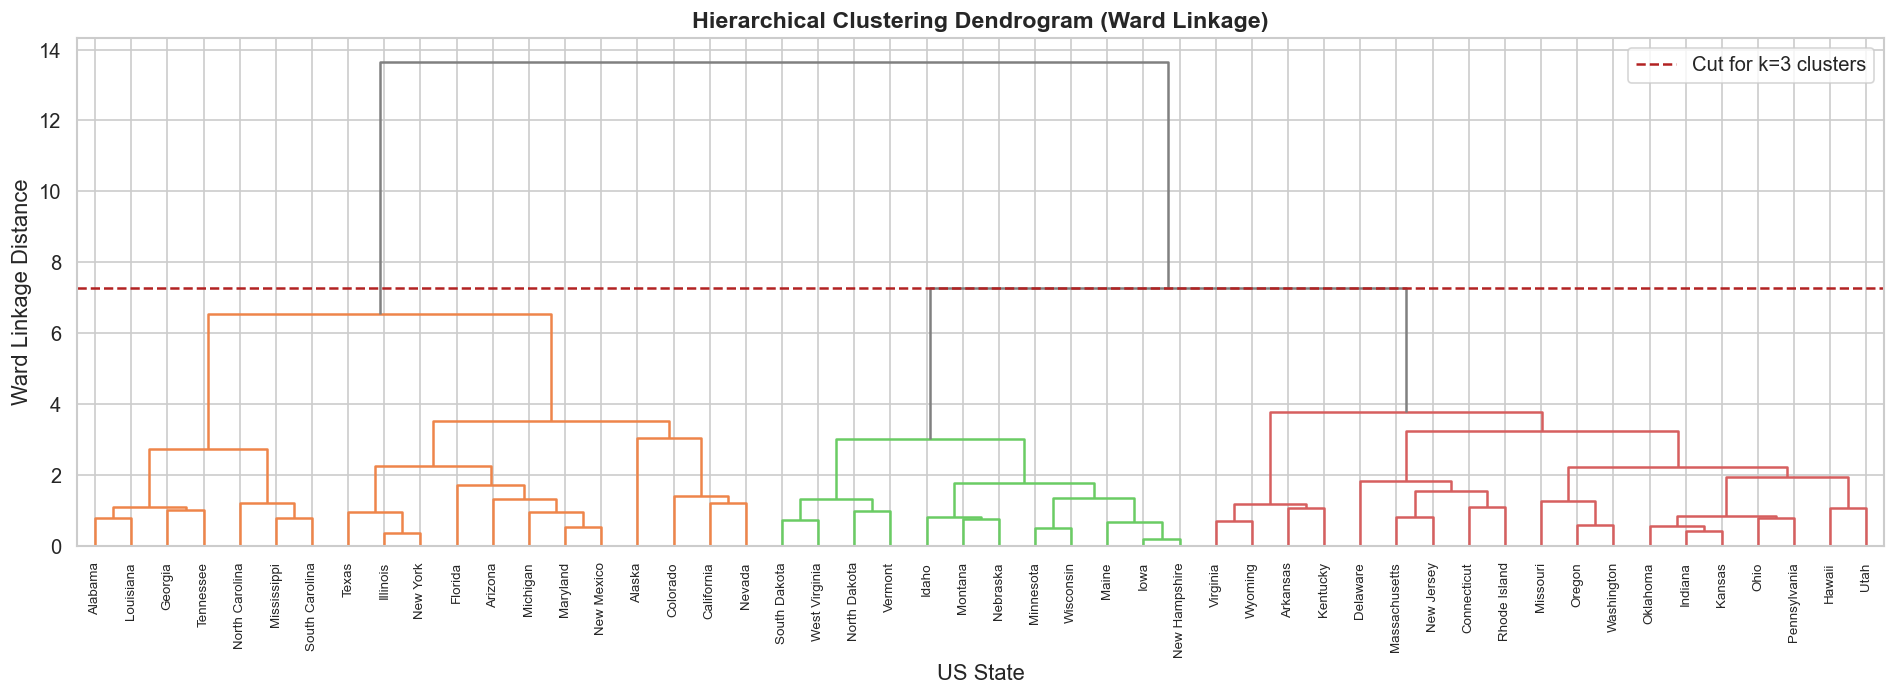

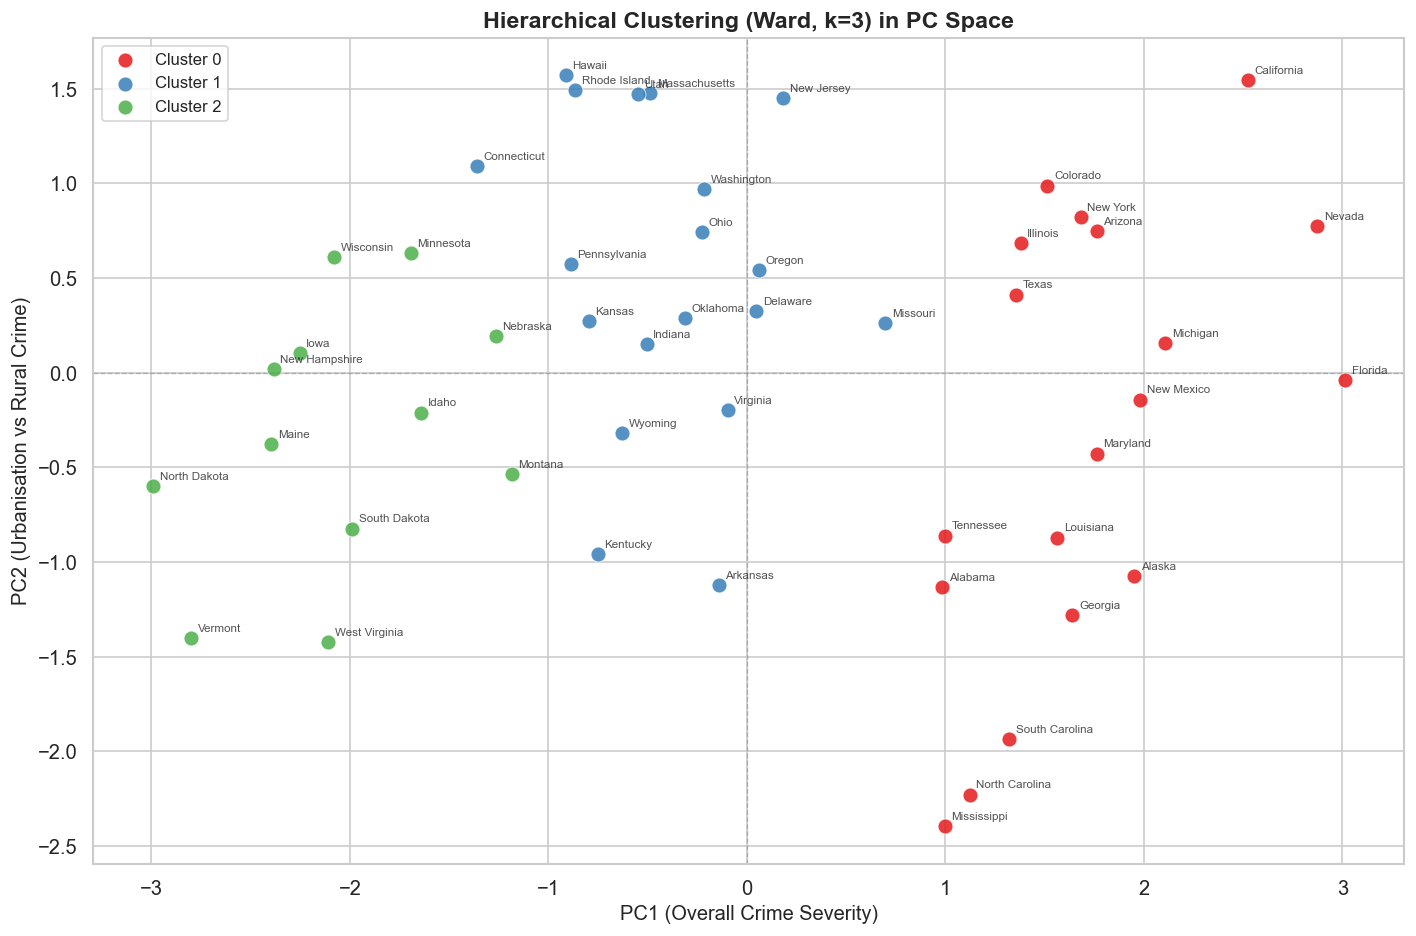

  Hierarchical Cluster Profiles (Mean Feature Values)
            Murder  Assault  UrbanPop   Rape
HC_Cluster                                  
0            12.33   259.32     68.32  29.22
1             6.21   142.05     71.26  19.18
2             3.09    76.00     52.08  11.83

  States per Cluster:

  Cluster 0 (19 states):
  Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, Texas

  Cluster 1 (19 states):
  Arkansas, Connecticut, Delaware, Hawaii, Indiana, Kansas, Kentucky, Massachusetts, Missouri, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming

  Cluster 2 (12 states):
  Idaho, Iowa, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

  Silhouette Score (k=3, Ward): 0.3963


In [40]:
scores_hc = run_hierarchical(df_scaled, scores_2[["PC1", "PC2"]])

## Interpretation:
- Hierarchical clustering with Ward linkage produces clusters that closely mirror the K-Means solution, lending confidence that the groupings are a genuine feature of the data rather than an artefact of the algorithm.
- The dendrogram reveals a clear three-cluster structure, the long vertical merges before the final join confirm that k=3 is a natural partition of the data.

# Section 12: Clustering Comparison

In [41]:
def compare_clusters(scores_kmeans, scores_hc):
    """
    Side-by-side scatter of K-Means vs Hierarchical cluster assignments
    in PC space to highlight agreement and any disagreements between
    the two methods.
    """
    combined = pd.DataFrame({
        "PC1":    scores_2["PC1"],
        "PC2":    scores_2["PC2"],
        "KMeans": scores_kmeans["KMeans_Cluster"],
        "HC":     scores_hc["HC_Cluster"]
    })

    # Map HC clusters to best-matching KMeans label for visual comparison
    # (cluster label integers may differ between algorithms)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    palette_km = sns.color_palette("Set2", 3)
    palette_hc = sns.color_palette("Set1", 3)

    for ax, method, col, palette in [
        (axes[0], "K-Means",       "KMeans", palette_km),
        (axes[1], "Hierarchical",  "HC",     palette_hc)
    ]:
        for cid in sorted(combined[col].unique()):
            mask = combined[col] == cid
            ax.scatter(combined.loc[mask, "PC1"],
                       combined.loc[mask, "PC2"],
                       s=70, color=palette[cid],
                       label=f"Cluster {cid}",
                       alpha=0.85, edgecolors="white",
                       linewidths=0.4, zorder=3)
            for state in combined.loc[mask].index:
                ax.annotate(state,
                            (combined.loc[state, "PC1"],
                             combined.loc[state, "PC2"]),
                            fontsize=6.5, alpha=0.75,
                            xytext=(3, 3), textcoords="offset points")

        ax.axhline(0, color="grey", linewidth=0.7, linestyle="--", alpha=0.4)
        ax.axvline(0, color="grey", linewidth=0.7, linestyle="--", alpha=0.4)
        ax.set_xlabel("PC1 (Overall Crime Severity)", fontsize=11)
        ax.set_title(f"{method} Clustering (k=3)",
                     fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)

    axes[0].set_ylabel("PC2 (Urbanisation vs Rural Crime)", fontsize=11)
    fig.suptitle("Comparison: K-Means vs Hierarchical Clustering",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("cluster_comparison.png", bbox_inches="tight")
    plt.show()


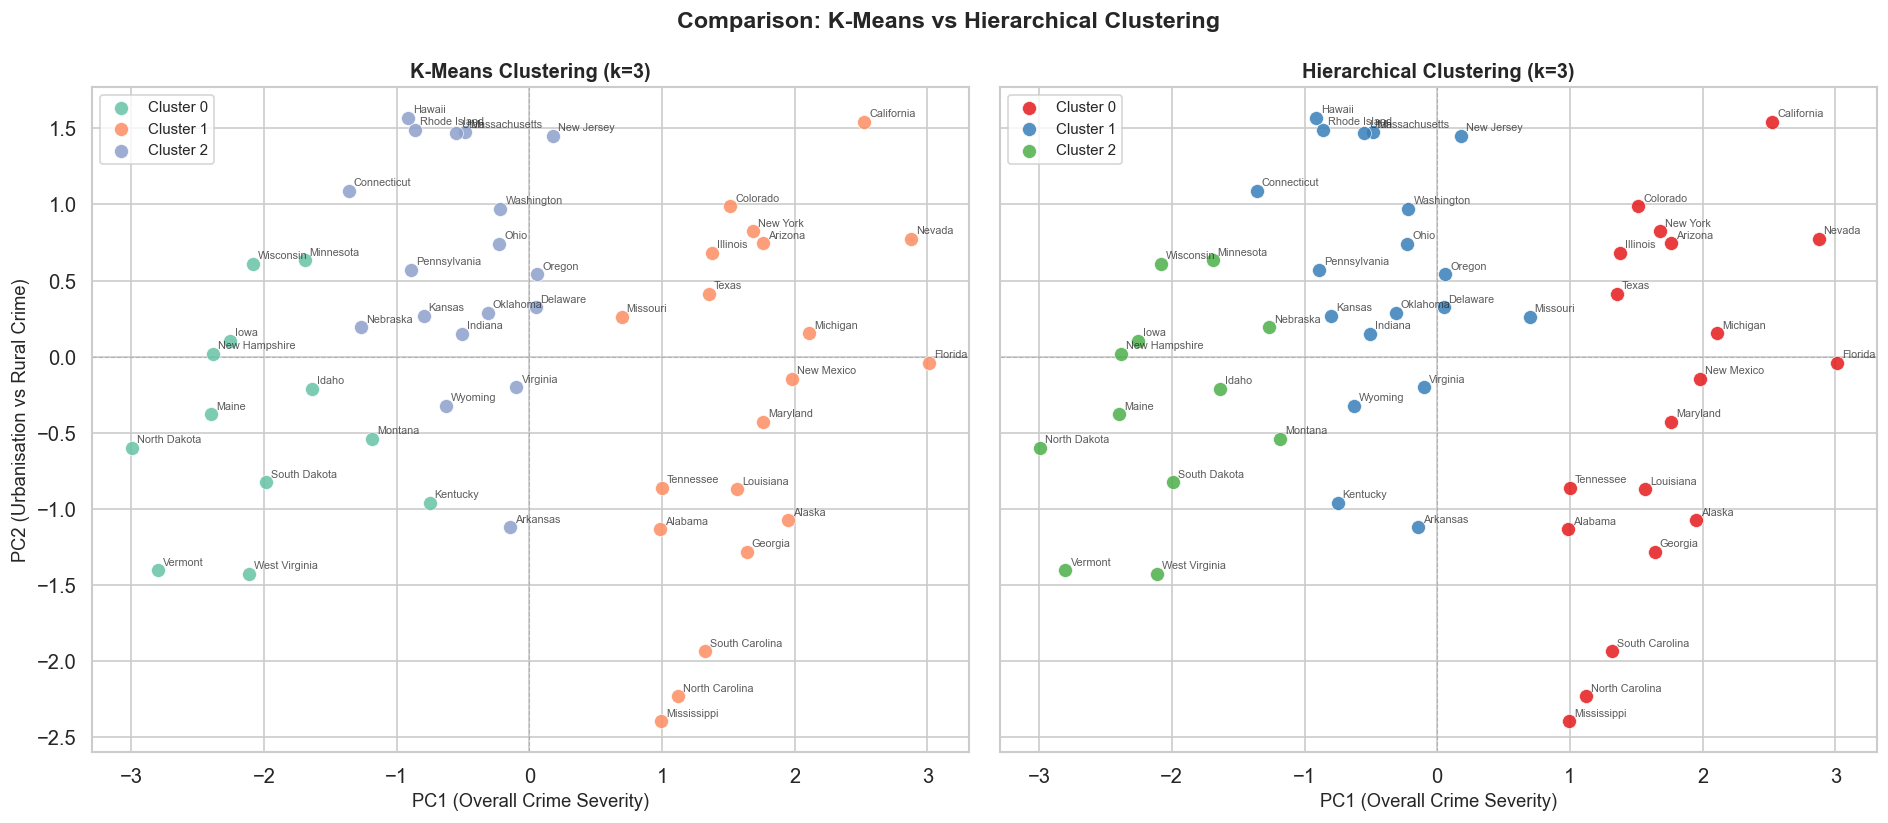

In [42]:
compare_clusters(scores_kmeans, scores_hc)

## Clustering Comparison Summary
Both K-Means and Hierarchical (Ward) clustering converge on
a consistent three-cluster structure when applied to the first
two principal components:

### High-crime states
 - Characterised by elevated murder, assault,
   and rape rates; predominantly in the South
   or with high urban populations (e.g. Florida,
   Nevada, California, Alabama, Georgia).

### Mid-crime states
- Moderate crime levels; varied urbanisation
  (e.g. Arkansas, Tennessee, Texas, Missouri).

### Low-crime states
- Consistently low crime across all three
                         variables; often small, rural states in the
                         Midwest or Northeast (e.g. North Dakota,
                         Vermont, Iowa, Wisconsin).

The strong agreement between two methodologically different algorithms increases confidence that these clusters reflect genuine structure in the 1973 US crime and urbanisation data.
Minor label reassignments at cluster boundaries are expected given the different objective functions (centroid vs. linkage).